# STEP 3: COINTEGRATION ANALYSIS & VECM
## Kiểm định quan hệ cân bằng dài hạn giữa các biến

### Mục tiêu:
1. **Johansen Cointegration Test** - Xác định số lượng cointegrating relationships
2. **VECM Estimation** - Vector Error Correction Model
3. **Long-run Relationships** - Các quan hệ cân bằng dài hạn
4. **Short-run Dynamics** - Điều chỉnh ngắn hạn
5. **Impulse Response & FEVD** - Phản ứng của hệ thống trước shock

## Setup & Configuration

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.vector_ar.vecm import select_order
import os
import warnings
warnings.filterwarnings('ignore')

SCRIPT_DIR = os.path.dirname(os.path.abspath('step3_cointegration_vecm.ipynb'))
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"Data Directory: {DATA_DIR}")

Data Directory: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed


## Load Data

In [55]:
cleaned_data = pd.read_csv(os.path.join(DATA_DIR, 'step1_cleaned_data.csv'))
cleaned_data['date'] = pd.to_datetime(cleaned_data['date'])
cleaned_data = cleaned_data.sort_values('date').reset_index(drop=True)

print(f"✓ Loaded cleaned data: {cleaned_data.shape[0]} months × {cleaned_data.shape[1]} columns")
print(f"Date range: {cleaned_data['date'].min().date()} to {cleaned_data['date'].max().date()}")
print(f"Missing values: {cleaned_data.isnull().sum().sum()}")
# lấy full danh sách các biến đã được làm sạch
num  = cleaned_data.select_dtypes(include=[np.number])
# Chọn biến cho VECM 
key_vars = ['cpi_mom', 'cpi_base_year','core_inflation_rate', 'm2','gasoline_world_last', 'silver_last','S&P500_last', 'USDVND_last', 'UPCOM_last','ppi_qoq']
available_vars = [v for v in key_vars if v in cleaned_data.columns]
print(f"\nKey variables for VECM: {available_vars}")

vecm_data = cleaned_data[['date'] + available_vars].copy()
vecm_data = vecm_data.dropna()
print(f"Data for VECM: {len(vecm_data)} observations × {len(available_vars)} variables")

✓ Loaded cleaned data: 95 months × 31 columns
Date range: 2018-06-01 to 2026-04-01
Missing values: 0

Key variables for VECM: ['cpi_mom', 'cpi_base_year', 'core_inflation_rate', 'm2', 'gasoline_world_last', 'silver_last', 'S&P500_last', 'USDVND_last', 'UPCOM_last', 'ppi_qoq']
Data for VECM: 95 observations × 10 variables


In [56]:
available_vars = [v for v in key_vars if v in cleaned_data.columns]
print(f"\nKey variables for VECM: {available_vars}")

vecm_data = cleaned_data[['date'] + available_vars].copy()
vecm_data = vecm_data.dropna()
print(f"Data for VECM: {len(vecm_data)} observations × {len(available_vars)} variables")


Key variables for VECM: ['cpi_mom', 'cpi_base_year', 'core_inflation_rate', 'm2', 'gasoline_world_last', 'silver_last', 'S&P500_last', 'USDVND_last', 'UPCOM_last', 'ppi_qoq']
Data for VECM: 95 observations × 10 variables


In [57]:
# in ra head của dữ liệu đã chuẩn bị cho VECM
print("\nSample of data prepared for VECM:")
print(vecm_data.head().to_string(index=False))


Sample of data prepared for VECM:
      date  cpi_mom  cpi_base_year  core_inflation_rate        m2  gasoline_world_last  silver_last  S&P500_last  USDVND_last  UPCOM_last  ppi_qoq
2018-06-01   100.61         159.11                 1.37 8879582.0               1.4334       16.104  2718.370117      22956.0       51.97     0.51
2018-07-01    99.91         159.11                 1.41 8842552.0               1.4858       15.500  2816.290039      23280.0       50.48     1.08
2018-08-01   100.45         159.11                 1.54 8888384.0               1.6443       14.438  2901.520020      23303.0       51.86     1.08
2018-09-01   100.59         159.11                 1.61 8933435.0               1.6214       14.623  2913.979980      23325.0       54.21     1.08
2018-10-01   100.33         159.11                 1.67 8999033.0               1.4189       14.229  2711.739990      23343.0       51.78     0.40


In [58]:
data_transformed = vecm_data.copy()
transform_decisions = []

# Lấy danh sách các biến số, loại bỏ cột 'date' nếu có
numeric_cols = [col for col in vecm_data.columns if col != 'date']

for col in numeric_cols:
    skewness = data_transformed[col].skew()
    kurtosis = data_transformed[col].kurtosis()

    # Log-transform nếu toàn bộ giá trị dương và skewness lớn
    if (data_transformed[col] > 0).all() and abs(skewness) > 1:
        data_transformed[f'{col}_log'] = np.log(data_transformed[col])
        transform_decisions.append({
            'Variable': col,
            'Transformation': 'Log',
            'Skewness_Before': skewness,
            'Kurtosis_Before': kurtosis,
            'Skewness_After': data_transformed[f'{col}_log'].skew(),
            'Kurtosis_After': data_transformed[f'{col}_log'].kurtosis(),
        })

    # Winsorize nếu kurtosis cao
    if kurtosis > 3:
        data_transformed[col] = data_transformed[col].clip(
            lower=data_transformed[col].quantile(0.01),
            upper=data_transformed[col].quantile(0.99)
        )
        transform_decisions.append({
            'Variable': col,
            'Transformation': 'Winsorization',
            'Skewness_Before': skewness,
            'Kurtosis_Before': kurtosis,
            'Skewness_After': data_transformed[col].skew(),
            'Kurtosis_After': data_transformed[col].kurtosis(),
        })

if transform_decisions:
    transform_df = pd.DataFrame(transform_decisions)
    print(f"\n  Transformations applied: {len(transform_df)}")
    print(f"\nFirst 10 transformations:")
    print(transform_df.head(10).to_string(index=False))
else:
    print("\n  No major transformations needed")


  Transformations applied: 3

First 10 transformations:
   Variable Transformation  Skewness_Before  Kurtosis_Before  Skewness_After  Kurtosis_After
    cpi_mom  Winsorization        -0.235645         3.809606        0.409612        1.466060
silver_last            Log         2.722262         8.017866        1.286136        2.180733
silver_last  Winsorization         2.722262         8.017866        2.586363        7.025711


In [59]:
# in ra head của dữ liệu đã chuẩn bị cho VECM
print("\nSample of data prepared for VECM:")
print(vecm_data.head().to_string(index=False))


Sample of data prepared for VECM:
      date  cpi_mom  cpi_base_year  core_inflation_rate        m2  gasoline_world_last  silver_last  S&P500_last  USDVND_last  UPCOM_last  ppi_qoq
2018-06-01   100.61         159.11                 1.37 8879582.0               1.4334       16.104  2718.370117      22956.0       51.97     0.51
2018-07-01    99.91         159.11                 1.41 8842552.0               1.4858       15.500  2816.290039      23280.0       50.48     1.08
2018-08-01   100.45         159.11                 1.54 8888384.0               1.6443       14.438  2901.520020      23303.0       51.86     1.08
2018-09-01   100.59         159.11                 1.61 8933435.0               1.6214       14.623  2913.979980      23325.0       54.21     1.08
2018-10-01   100.33         159.11                 1.67 8999033.0               1.4189       14.229  2711.739990      23343.0       51.78     0.40


## PART 1: Stationarity Assessment

In [60]:

stationarity_results = []

for var in available_vars:
    series = vecm_data[var].dropna()
    
    # Level test
    try:
        adf_level = adfuller(series, autolag='AIC')
        level_pval = adf_level[1]
    except:
        level_pval = np.nan
    
    # First difference test
    try:
        diff_series = series.diff().dropna()
        adf_diff = adfuller(diff_series, autolag='AIC')
        diff_pval = adf_diff[1]
    except:
        diff_pval = np.nan
    
    # Classification
    if level_pval > 0.05 and diff_pval < 0.05:
        integration = 'I(1) ✓'
    elif level_pval < 0.05:
        integration = 'I(0) - Stationary'
    else:
        integration = 'I(2) or higher'
    
    stationarity_results.append({
        'Variable': var,
        'Level_p_value': level_pval,
        'Diff_p_value': diff_pval,
        'Integration': integration
    })
    
    print(f"\n{var}:")
    print(f"  Level ADF p-value: {level_pval:.4f} {'(Non-stationary)' if level_pval > 0.05 else '(Stationary)'}")
    print(f"  First diff p-value: {diff_pval:.4f} {'(Stationary)' if diff_pval < 0.05 else '(Non-stationary)'}")
    print(f"  → {integration}")

stationarity_df = pd.DataFrame(stationarity_results)
print(f"\n\nSummary:")
print(stationarity_df.to_string(index=False))


cpi_mom:
  Level ADF p-value: 0.0000 (Stationary)
  First diff p-value: 0.0000 (Stationary)
  → I(0) - Stationary

cpi_base_year:
  Level ADF p-value: 0.5261 (Non-stationary)
  First diff p-value: 0.7018 (Non-stationary)
  → I(2) or higher

core_inflation_rate:
  Level ADF p-value: 0.2592 (Non-stationary)
  First diff p-value: 0.0017 (Stationary)
  → I(1) ✓

m2:
  Level ADF p-value: 0.5491 (Non-stationary)
  First diff p-value: 0.0000 (Stationary)
  → I(1) ✓

gasoline_world_last:
  Level ADF p-value: 0.5166 (Non-stationary)
  First diff p-value: 0.0000 (Stationary)
  → I(1) ✓

silver_last:
  Level ADF p-value: 0.9984 (Non-stationary)
  First diff p-value: 0.0000 (Stationary)
  → I(1) ✓

S&P500_last:
  Level ADF p-value: 0.9777 (Non-stationary)
  First diff p-value: 0.0000 (Stationary)
  → I(1) ✓

USDVND_last:
  Level ADF p-value: 0.9844 (Non-stationary)
  First diff p-value: 0.0000 (Stationary)
  → I(1) ✓

UPCOM_last:
  Level ADF p-value: 0.7510 (Non-stationary)
  First diff p-value: 

## PART 2: Johansen Cointegration Test

In [61]:
vecm_vars =  ['core_inflation_rate', 'm2','gasoline_world_last', 'silver_last','S&P500_last', 'USDVND_last', 'UPCOM_last','ppi_qoq']
endog = vecm_data[vecm_vars].values

# Johansen test with trace and eigenvalue statistics
result = coint_johansen(endog, det_order=0, k_ar_diff=1)

# Extract test results
trace_stat = result.lr1  # Trace statistic
trace_cv = result.cvt   # Critical values (90%, 95%, 99%)
eigen_stat = result.lr2  # Eigenvalue statistic
eigen_cv = result.cvm   # Critical values

print("\nTRACE TEST (H0: at most r cointegrating relationships):")
print(f"{'Rank':<6} {'Statistic':<12} {'90%':<10} {'95%':<10} {'99%':<10} {'Decision':<20}")
print("-" * 70)

for i in range(len(trace_stat)):
    stat = trace_stat[i]
    cv_90, cv_95, cv_99 = trace_cv[i, :]
    
    if stat > cv_99:
        decision = "Reject (99%)"
    elif stat > cv_95:
        decision = "Reject (95%)"
    elif stat > cv_90:
        decision = "Reject (90%)"
    else:
        decision = "Do not reject"
    
    print(f"{i:<6} {stat:<12.4f} {cv_90:<10.4f} {cv_95:<10.4f} {cv_99:<10.4f} {decision:<20}")

print("\n\nEIGENVALUE TEST (H0: at most r cointegrating relationships):")
print(f"{'Rank':<6} {'Statistic':<12} {'90%':<10} {'95%':<10} {'99%':<10} {'Decision':<20}")
print("-" * 70)

for i in range(len(eigen_stat)):
    stat = eigen_stat[i]
    cv_90, cv_95, cv_99 = eigen_cv[i, :]
    
    if stat > cv_99:
        decision = "Reject (99%)"
    elif stat > cv_95:
        decision = "Reject (95%)"
    elif stat > cv_90:
        decision = "Reject (90%)"
    else:
        decision = "Do not reject"
    
    print(f"{i:<6} {stat:<12.4f} {cv_90:<10.4f} {cv_95:<10.4f} {cv_99:<10.4f} {decision:<20}")

print(f"\n✓ Eigenvalues (λ): {result.eig[0]}")
print(f"✓ Cointegrating vectors (beta):")
print(result.evec)


TRACE TEST (H0: at most r cointegrating relationships):
Rank   Statistic    90%        95%        99%        Decision            
----------------------------------------------------------------------
0      227.5802     153.6341   159.5290   171.0905   Reject (99%)        
1      139.0395     120.3673   125.6185   135.9825   Reject (99%)        
2      88.5368      91.1090    95.7542    104.9637   Do not reject       
3      50.9402      65.8202    69.8189    77.8202    Do not reject       
4      23.2505      44.4929    47.8545    54.6815    Do not reject       
5      10.6123      27.0669    29.7961    35.4628    Do not reject       
6      5.3224       13.4294    15.4943    19.9349    Do not reject       
7      0.2207       2.7055     3.8415     6.6349     Do not reject       


EIGENVALUE TEST (H0: at most r cointegrating relationships):
Rank   Statistic    90%        95%        99%        Decision            
---------------------------------------------------------------------

In [ ]:


# Tạo dataframe mới với dữ liệu đã log
vecm_data_log = vecm_data.copy()

# Log transform tất cả các biến (ngoại trừ date)
log_vars = []
for col in vecm_vars:
    if (vecm_data_log[col] > 0).all():  # Chỉ log nếu tất cả giá trị dương
        vecm_data_log[f'{col}_log'] = np.log(vecm_data_log[col])
        log_vars.append(f'{col}_log')
        print(f"✓ Log-transformed: {col}")
    else:
        # Nếu không thể log, vẫn dùng biến gốc
        log_vars.append(col)
        print(f"⚠ Cannot log {col} (contains non-positive): using original scale")

# Sử dụng biến log/original cho VECM
vecm_vars_log = log_vars

print(f"\n✓ Data preparation complete")
print(f"Variables for VECM: {vecm_vars_log}\n")

# Chuẩn bị dữ liệu cho mô hình
endog = vecm_data_log[vecm_vars_log].values

print(f"Data shape: {endog.shape}")
print(f"Sample (first 3 rows):")
print(pd.DataFrame(endog[:3], columns=vecm_vars_log).to_string(index=False))


[LOG TRANSFORM OF INPUT VARIABLES]

✓ Log-transformed: core_inflation_rate
⚠ Cannot log m2 (contains non-positive): using original scale
✓ Log-transformed: gasoline_world_last
✓ Log-transformed: silver_last
✓ Log-transformed: S&P500_last
✓ Log-transformed: USDVND_last
✓ Log-transformed: UPCOM_last
⚠ Cannot log ppi_qoq (contains non-positive): using original scale

✓ Data preparation complete
Variables for VECM: ['core_inflation_rate_log', 'm2', 'gasoline_world_last_log', 'silver_last_log', 'S&P500_last_log', 'USDVND_last_log', 'UPCOM_last_log', 'ppi_qoq']

Data shape: (95, 8)
Sample (first 3 rows):
 core_inflation_rate_log        m2  gasoline_world_last_log  silver_last_log  S&P500_last_log  USDVND_last_log  UPCOM_last_log  ppi_qoq
                0.314811 8879582.0                 0.360049         2.779068         7.907788        10.041335        3.950667     0.51
                0.343590 8842552.0                 0.395953         2.740840         7.943176        10.055350        3.9

## PART 3: VECM Model Selection & Estimation

In [63]:

lag_order = select_order(endog, maxlags=4, deterministic='ci')
print(lag_order.summary())

print(f"  AIC: {lag_order.aic}")
print(f"  BIC: {lag_order.bic}")

k_ar_diff = lag_order.aic
print(f"\nUsing k_ar_diff = {k_ar_diff} for VECM")

 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -6.743     -4.521*   0.001188*     -5.847*
1      -6.093      -2.093    0.002359      -4.480
2      -5.912     -0.1346    0.003099      -3.582
3      -6.674      0.8805    0.001730      -3.628
4     -6.801*       2.531    0.002080      -3.038
-------------------------------------------------
  AIC: 4
  BIC: 0

Using k_ar_diff = 4 for VECM


In [64]:

r = 2 # lấy từ JS 

vecm_model = VECM(endog, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci')
vecm_result = vecm_model.fit()

print(vecm_result.summary())

print(f"\n✓ VECM model estimated with {r} cointegrating relationship(s)")
print(f"\nModel diagnostics:")
print(f"  Log-likelihood: {vecm_result.llf:.2f}")


Det. terms outside the coint. relation & lagged endog. parameters for equation y1
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.y1          0.2432      0.106      2.283      0.022       0.034       0.452
L1.y2      -1.016e-08      1e-08     -1.015      0.310   -2.98e-08    9.47e-09
L1.y3          0.3561      0.320      1.114      0.265      -0.270       0.983
L1.y4          0.3273      0.258      1.270      0.204      -0.178       0.832
L1.y5         -1.1961      0.562     -2.130      0.033      -2.297      -0.096
L1.y6          7.7580      2.726      2.846      0.004       2.415      13.101
L1.y7          0.4152      0.517      0.804      0.422      -0.598       1.428
L1.y8          0.1140      0.046      2.491      0.013       0.024       0.204
L2.y1         -0.0334      0.106     -0.316      0.752      -0.241       0.174
L2.y2       -1.04e-08      1e-08     -1.039      

## PART 4: Long-run & Short-run Relationships

In [65]:
print("Long-run cointegrating vector (β):")
print("If variables move together in the long run, this vector captures the relationship")
print(f"\nβ = {vecm_result.beta}")

print("\n\nAdjustment coefficients (α):")
print("Speed at which each variable adjusts to deviations from long-run equilibrium")
print(f"\nα = {vecm_result.alpha}")

print("\n\nError Correction Term (α·β'·Δt):")
print("Speed of adjustment to equilibrium (higher α = faster adjustment to long-run equilibrium)")
for i, var in enumerate(vecm_vars_log):
    adjustment = vecm_result.alpha[i, 0]
    print(f"  {var}: {adjustment:.4f}")

Long-run cointegrating vector (β):
If variables move together in the long run, this vector captures the relationship

β = [[ 1.00000000e+00 -2.41288779e-10]
 [-7.32670809e-25  1.00000000e+00]
 [-2.45880419e+00  6.96971958e+06]
 [-3.43492587e-01  2.35883240e+07]
 [-2.21664189e+00 -5.90203759e+07]
 [ 2.67295910e+00  8.64072675e+07]
 [ 3.65188183e+00  1.51900003e+07]
 [ 5.29080857e-01  2.63201843e+06]]


Adjustment coefficients (α):
Speed at which each variable adjusts to deviations from long-run equilibrium

α = [[-2.36406637e-01  8.33948615e-09]
 [ 2.19788754e+06 -3.22637440e-01]
 [ 2.76619033e-03  1.25217846e-08]
 [ 3.42513111e-02 -3.18998061e-10]
 [-3.56109612e-02  7.06353784e-09]
 [ 1.75138380e-02 -6.28659057e-11]
 [-5.47120080e-02  3.50257663e-09]
 [-4.37976370e-01 -6.86577494e-08]]


Error Correction Term (α·β'·Δt):
Speed of adjustment to equilibrium (higher α = faster adjustment to long-run equilibrium)
  core_inflation_rate_log: -0.2364
  m2: 2197887.5383
  gasoline_world_last_lo

## PART 5: Impulse Response Analysis

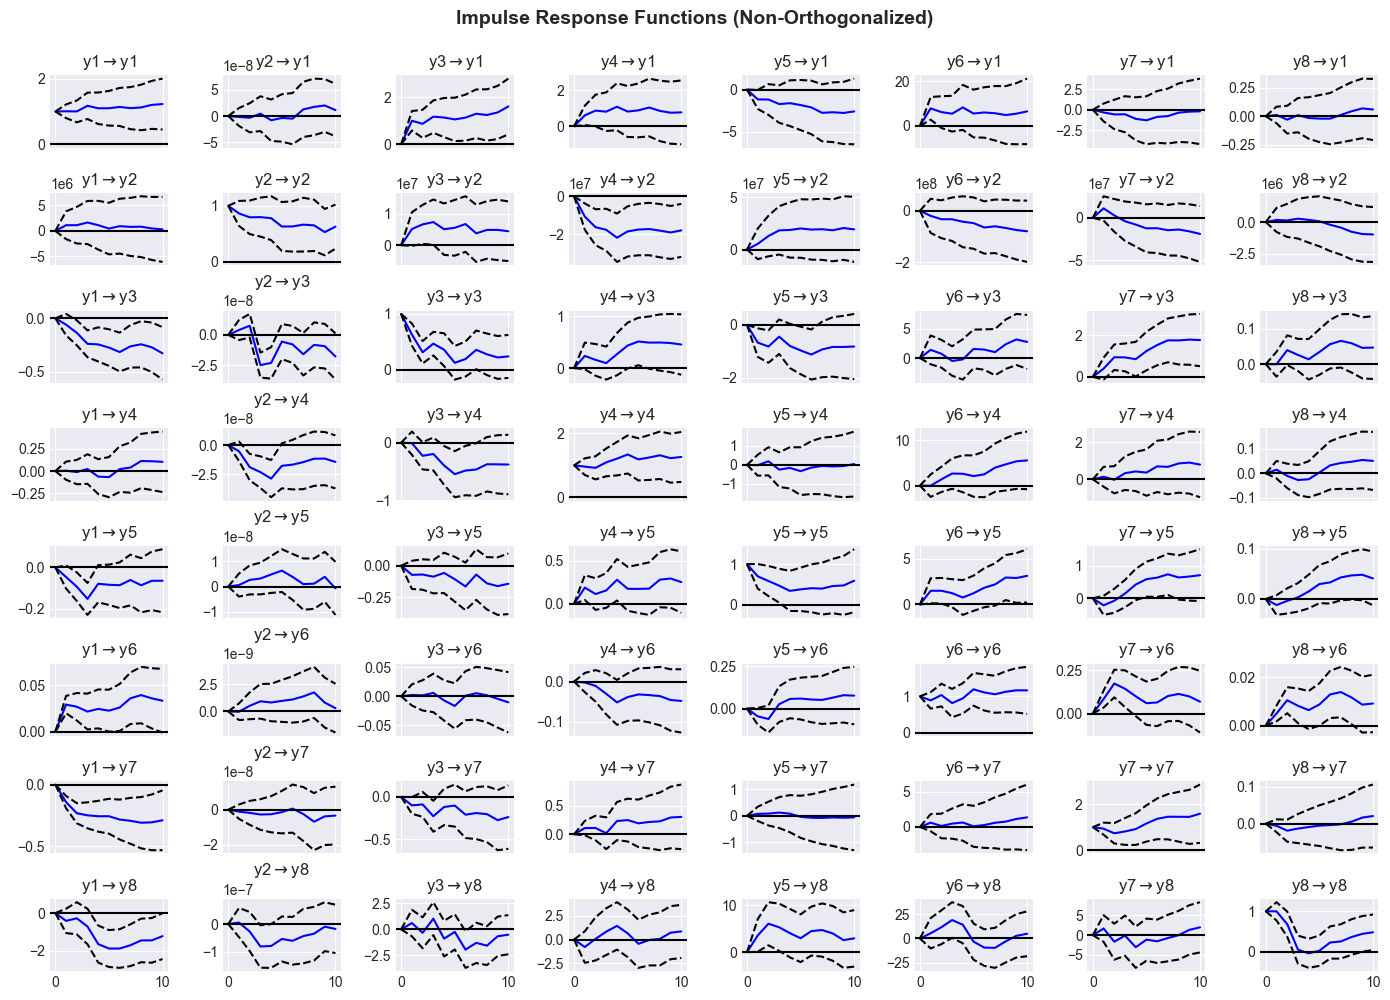

✓ Impulse response functions plotted (non-orthogonalized)
  Interpretation: Effect on variable j from a 1-unit shock in variable i


In [66]:

irf = vecm_result.irf(10)  

# Plot IRF
fig = irf.plot(orth=False, impulse=None, response=None, figsize=(14, 10))
plt.suptitle('Impulse Response Functions (Non-Orthogonalized)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Impulse response functions plotted (non-orthogonalized)")
print(f"  Interpretation: Effect on variable j from a 1-unit shock in variable i")

## PART 6: Forecast Error Variance Decomposition

In [67]:

irf = vecm_result.irf(10)

irfs = irf.irfs  

# Tính FEVD thủ công
horizons = [1, 5, 10]
for h in horizons:

    fevd = np.zeros((len(vecm_vars_log), len(vecm_vars_log)))
    
    for i in range(len(vecm_vars_log)):  
        for j in range(len(vecm_vars_log)):  
            cumulative_irf_sq = np.sum(irfs[:h, i, j]**2)
            total_variance = np.sum(irfs[:h, i, :]**2)
            if total_variance > 0:
                fevd[i, j] = (cumulative_irf_sq / total_variance) * 100

    for i, var in enumerate(vecm_vars_log):
        print(f"\n{var}:")
        for j, shock_var in enumerate(vecm_vars_log):
            print(f"  From {shock_var}: {fevd[i, j]:6.2f}%")


core_inflation_rate_log:
  From core_inflation_rate_log: 100.00%
  From m2:   0.00%
  From gasoline_world_last_log:   0.00%
  From silver_last_log:   0.00%
  From S&P500_last_log:   0.00%
  From USDVND_last_log:   0.00%
  From UPCOM_last_log:   0.00%
  From ppi_qoq:   0.00%

m2:
  From core_inflation_rate_log:   0.00%
  From m2: 100.00%
  From gasoline_world_last_log:   0.00%
  From silver_last_log:   0.00%
  From S&P500_last_log:   0.00%
  From USDVND_last_log:   0.00%
  From UPCOM_last_log:   0.00%
  From ppi_qoq:   0.00%

gasoline_world_last_log:
  From core_inflation_rate_log:   0.00%
  From m2:   0.00%
  From gasoline_world_last_log: 100.00%
  From silver_last_log:   0.00%
  From S&P500_last_log:   0.00%
  From USDVND_last_log:   0.00%
  From UPCOM_last_log:   0.00%
  From ppi_qoq:   0.00%

silver_last_log:
  From core_inflation_rate_log:   0.00%
  From m2:   0.00%
  From gasoline_world_last_log:   0.00%
  From silver_last_log: 100.00%
  From S&P500_last_log:   0.00%
  From USDVN

## PART 7: Model Validation & Forecasting

- chia train/test
- fit mô hình VECM
- đánh giá train
- dự báo test
- tính metric forecast
- so sánh train vs test

In [68]:

train_size = int(len(endog) * 0.8)  
test_size = len(endog) - train_size 

endog_train = endog[:train_size, :]
endog_test = endog[train_size:, :]

print(f"Training set: {train_size} observations (80%)")
print(f"Test set: {test_size} observations (20%)")
print(f"Train period: {vecm_data['date'].iloc[0].strftime('%Y-%m-%d')} to {vecm_data['date'].iloc[train_size-1].strftime('%Y-%m-%d')}")
print(f"Test period: {vecm_data['date'].iloc[train_size].strftime('%Y-%m-%d')} to {vecm_data['date'].iloc[-1].strftime('%Y-%m-%d')}")

vecm_model_train = VECM(endog_train, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci')
vecm_result_train = vecm_model_train.fit() # fit mh 


residuals_train = vecm_result_train.resid # phần dư
fittedvalues_train = vecm_result_train.fittedvalues # giá trị dự báo in - sample 

print(f"\n{'Variable':<30} {'R²':<10} {'RMSE':<12} {'MAE':<12} {'MAPE (%)':<12}")

train_metrics = {}
for i, var in enumerate(vecm_vars_log):
    predicted_train = fittedvalues_train[:, i]
    actual_train = predicted_train + residuals_train[:, i]
    
    rmse_train = np.sqrt(np.mean((actual_train - predicted_train)**2))
    mae_train = np.mean(np.abs(actual_train - predicted_train))
    
    mape_values = np.abs((actual_train - predicted_train) / np.where(actual_train != 0, actual_train, 1))
    mape_train = np.mean(mape_values[actual_train != 0]) * 100 if np.any(actual_train != 0) else 0

    ss_res = np.sum((actual_train - predicted_train)**2)
    ss_tot = np.sum((actual_train - np.mean(actual_train))**2)
    r_squared_train = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    train_metrics[var] = {
        'R²': r_squared_train,
        'RMSE': rmse_train,
        'MAE': mae_train,
        'MAPE': mape_train
    }
    
    print(f"{var:<30} {r_squared_train:<10.4f} {rmse_train:<12.4f} {mae_train:<12.4f} {mape_train:<12.2f}")


print(f"Fitting VECM on complete training set ({train_size} observations)...")
vecm_model_train_final = VECM(endog_train, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci')
vecm_result_train_final = vecm_model_train_final.fit()


Training set: 76 observations (80%)
Test set: 19 observations (20%)
Train period: 2018-06-01 to 2024-09-01
Test period: 2024-10-01 to 2026-04-01

Variable                       R²         RMSE         MAE          MAPE (%)    
core_inflation_rate_log        0.9462     0.1416       0.1055       50.62       
m2                             0.9976     108324.5233  84825.3688   0.68        
gasoline_world_last_log        0.9131     0.0669       0.0502       12.62       
silver_last_log                0.9005     0.0657       0.0537       1.76        
S&P500_last_log                0.9663     0.0388       0.0306       0.37        
USDVND_last_log                0.9824     0.0039       0.0030       0.03        
UPCOM_last_log                 0.9842     0.0308       0.0233       0.54        
ppi_qoq                        0.8385     0.3565       0.2658       116.19      
Fitting VECM on complete training set (76 observations)...


In [69]:

irf_train = vecm_result_train_final.irf(1)  
mean_residuals_train = np.mean(vecm_result_train_final.resid, axis=0)

test_results = {var: {'actual': [], 'predicted': []} for var in vecm_vars_log}

current_state = endog_train[-1, :].copy() 

for i in range(test_size):
    try:
        actual_values = endog_test[i, :]
        irf_1step = vecm_result_train_final.irf(1)
        impulse_effect = irf_1step.irfs[0, :, :] @ mean_residuals_train
        forecast_mean = current_state + impulse_effect

        for j, var in enumerate(vecm_vars_log):
            test_results[var]['actual'].append(actual_values[j])
            test_results[var]['predicted'].append(forecast_mean[j])
        
        current_state = actual_values.copy()
        
        if (i + 1) % 5 == 0:
            print(f"  Completed {i+1}/{test_size} forecasts...")
    except Exception as e:
        print(f"  Warning at test index {i}: {str(e)}")
        continue
# in 
print(f"\n{'Variable':<30} {'R²':<10} {'RMSE':<12} {'MAE':<12} {'MAPE (%)':<12}")

test_metrics = {}
for var in vecm_vars_log:
    actual = np.array(test_results[var]['actual'])
    predicted = np.array(test_results[var]['predicted'])
    rmse_test = np.sqrt(np.mean((actual - predicted)**2))
    mae_test = np.mean(np.abs(actual - predicted))
    non_zero_mask = actual != 0
    if np.any(non_zero_mask):
        mape_test = np.mean(np.abs((actual[non_zero_mask] - predicted[non_zero_mask]) / np.abs(actual[non_zero_mask]))) * 100
    else:
        mape_test = 0

    ss_res = np.sum((actual - predicted)**2)
    ss_tot = np.sum((actual - np.mean(actual))**2)
    r_squared_test = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    test_metrics[var] = {
        'R²': r_squared_test,
        'RMSE': rmse_test,
        'MAE': mae_test,
        'MAPE': mape_test
    }
    
    print(f"{var:<30} {r_squared_test:<10.4f} {rmse_test:<12.4f} {mae_test:<12.4f} {mape_test:<12.2f}")

  Completed 5/19 forecasts...
  Completed 10/19 forecasts...
  Completed 15/19 forecasts...

Variable                       R²         RMSE         MAE          MAPE (%)    
core_inflation_rate_log        0.6786     0.0527       0.0396       3.42        
m2                             0.7401     4595374.1460 1222791.0404 1.38        
gasoline_world_last_log        0.3280     0.1501       0.0649       7.17        
silver_last_log                0.9159     0.1107       0.0931       2.37        
S&P500_last_log                0.7685     0.0370       0.0296       0.34        
USDVND_last_log                0.5649     0.0108       0.0076       0.08        
UPCOM_last_log                 0.9114     0.0354       0.0294       0.63        
ppi_qoq                        0.2518     0.7038       0.3442       53.79       


In [85]:
print(f"\n{'Variable':<25} {'Train R²':<12} {'Test R²':<12} {'Difference':<15} {'Status':<15}")

for var in vecm_vars_log:
    train_r2 = train_metrics[var]['R²']
    test_r2 = test_metrics[var]['R²']
    diff = test_r2 - train_r2
    status = "Good fit" if test_r2 > 0.7 else " Moderate" if test_r2 > 0.5 else "Poor fit"
    
    print(f"{var:<25} {train_r2:<12.4f} {test_r2:<12.4f} {diff:>+14.4f} {status:<15}")


Variable                  Train R²     Test R²      Difference      Status         
core_inflation_rate_log   0.9462       0.6786              -0.2676  Moderate      
m2                        0.9976       0.7401              -0.2574 Good fit       
gasoline_world_last_log   0.9131       0.3280              -0.5850 Poor fit       
silver_last_log           0.9005       0.9159              +0.0153 Good fit       
S&P500_last_log           0.9663       0.7685              -0.1978 Good fit       
USDVND_last_log           0.9824       0.5649              -0.4175  Moderate      
UPCOM_last_log            0.9842       0.9114              -0.0727 Good fit       
ppi_qoq                   0.8385       0.2518              -0.5867 Poor fit       


Cải thiện mô hình VECM bằng các tham số khác nhau, chọn số lượng lags (k_ar_diff) và cointegration rank (r) tối ưu dựa trên AIC/BIC và kết quả kiểm định Johansen: 

## PART 8: MODEL DIAGNOSTICS

Kiểm tra tự tương quan, phân phối chuẩn và thay đổi cấu trúc của VECM

In [91]:
from scipy.stats import chi2
import numpy as np

residuals = vecm_result_train_final.resid
T = residuals.shape[0]
K = residuals.shape[1]

k_diff = k_ar_diff
r_rank = r

lags_to_test = [1, 2, 3, 4, 5, 10, 15]

C0 = residuals.T @ residuals / T
C0_inv = np.linalg.pinv(C0)

print(f"\n{'Lag':<6} {'Portmanteau':<15} {'df':<8} {'p-value':<12}")
print("-" * 50)

for h in lags_to_test:
    portm_sum = 0
    
    for i in range(1, h + 1):
        C_i = residuals[i:].T @ residuals[:-i] / T
        
        term_i = C_i.T @ C0_inv @ C_i @ C0_inv
        portm_sum += np.trace(term_i)
    
    portm_stat = T * portm_sum
    
    portm_dof = h * K * K - K * K * k_diff - K * r_rank
    
    if portm_dof <= 0:
        pval = np.nan
    else:
        pval = chi2.sf(portm_stat, portm_dof)
    
    print(f"{h:<6} {portm_stat:<15.4f} {portm_dof:<8} {pval:<12.4f}")


Lag    Portmanteau     df       p-value     
--------------------------------------------------
1      20.7392         -208     nan         
2      39.5763         -144     nan         
3      66.6318         -80      nan         
4      87.0427         -16      nan         
5      132.0525        48       0.0000      
10     335.4342        368      0.8874      
15     555.7170        688      0.9999      


Không diễn giải được Portmanteau test tại lag 1–4 vì bậc tự do âm.
Mô hình không có vấn đề tự tương quan rõ ràng ở lag lớn. 

In [94]:

from scipy.stats import skew, kurtosis, jarque_bera
import numpy as np

print("\nInterpretation: p-value > 0.05 → Fail to reject normality")
print("                Skewness ≈ 0, Excess Kurtosis ≈ 0 → Closer to normal distribution")
print(f"\n{'Variable':<30} {'Skewness':<12} {'Ex.Kurtosis':<12} {'JB Stat':<12} {'p-value':<12}")


for i, var in enumerate(vecm_vars_log):
    res_i = residuals[:, i]
    res_i = res_i[~np.isnan(res_i)]
    
    skewness = skew(res_i)
    ex_kurt = kurtosis(res_i)  # Fisher=True by default, normal = 0
    jb_stat, jb_pval = jarque_bera(res_i)
    
    print(f"{var:<30} {skewness:<12.4f} {ex_kurt:<12.4f} {jb_stat:<12.4f} {jb_pval:<12.4f}")



Interpretation: p-value > 0.05 → Fail to reject normality
                Skewness ≈ 0, Excess Kurtosis ≈ 0 → Closer to normal distribution

Variable                       Skewness     Ex.Kurtosis  JB Stat      p-value     
core_inflation_rate_log        0.7498       2.4374       24.2266      0.0000      
m2                             -0.4837      0.5328       3.6077       0.1647      
gasoline_world_last_log        -0.0880      2.0641       12.6950      0.0018      
silver_last_log                0.5091       -0.0793      3.0853       0.2138      
S&P500_last_log                -0.4439      -0.0451      2.3383       0.3106      
USDVND_last_log                0.1821       0.0081       0.3924       0.8219      
UPCOM_last_log                 0.4199       -0.0248      2.0885       0.3519      
ppi_qoq                        1.0072       3.3028       44.2767      0.0000      


Kết quả Jarque-Bera đơn biến cho thấy phần dư của mô hình VECM không hoàn toàn tuân theo phân phối chuẩn. Cụ thể, phần dư của core_inflation_rate_log, gasoline_world_last_log và ppi_qoq bị bác bỏ giả thuyết chuẩn tính ở mức ý nghĩa 5%

In [95]:

import numpy as np
from scipy.stats import chi2
from statsmodels.tsa.vector_ar.vecm import VECM

# Split data
T1 = train_size // 2
endog_1 = endog_train[:T1, :]
endog_2 = endog_train[T1:, :]

# Estimate VECM for each period
vecm_1 = VECM(endog_1, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci').fit()
vecm_2 = VECM(endog_2, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci').fit()

# Estimate full sample VECM
vecm_full = VECM(endog_train, k_ar_diff=k_ar_diff, coint_rank=r, deterministic='ci').fit()

# Residuals
u1 = vecm_1.resid
u2 = vecm_2.resid
uf = vecm_full.resid

T1_eff = u1.shape[0]
T2_eff = u2.shape[0]
T_eff = uf.shape[0]
K = uf.shape[1]

# Covariance matrices
S1 = (u1.T @ u1) / T1_eff
S2 = (u2.T @ u2) / T2_eff
Sf = (uf.T @ uf) / T_eff

# Use slogdet for numerical stability
sign1, logdet1 = np.linalg.slogdet(S1)
sign2, logdet2 = np.linalg.slogdet(S2)
signf, logdetf = np.linalg.slogdet(Sf)

if sign1 <= 0 or sign2 <= 0 or signf <= 0:
    print("Warning: covariance matrix is not positive definite.")
else:
    # LR statistic
    lr_stat = T_eff * logdetf - T1_eff * logdet1 - T2_eff * logdet2

    # Degrees of freedom
    df = r * (K - r) + r * K + k_ar_diff * K * K

    # If deterministic='ci', you may add r restrictions if testing intercept in cointegration too
    # df = df + r

    pval = chi2.sf(lr_stat, df)

    print(f"\nSplit at observation: {T1}")
    print(f"Effective sample sizes: T1={T1_eff}, T2={T2_eff}, Full={T_eff}")
    print(f"LR Chow Statistic: {lr_stat:.4f}")
    print(f"df: {df}")
    print(f"p-value: {pval:.4f}")

    if pval < 0.05:
        print("Conclusion: Structural break detected (reject H0)")
    else:
        print("Conclusion: No significant structural break")



Split at observation: 38
Effective sample sizes: T1=33, T2=33, Full=71
LR Chow Statistic: 25612.9772
df: 284
p-value: 0.0000
Conclusion: Structural break detected (reject H0)


Mối quan hệ giữa core inflation, M2, gasoline, silver, S&P500, USDVND, UPCOM và PPI không ổn định trong toàn bộ mẫu train.

Không nên giữ nguyên VECM 8 biến

In [98]:

import numpy as np
from scipy.stats import f as f_dist



test_size = endog_test.shape[0]

test_preds = vecm_result_train_final.predict(steps=test_size)

print("test_preds shape:", test_preds.shape)
print("endog_test shape:", endog_test.shape)

if test_preds.shape != endog_test.shape:
    raise ValueError("Shape mismatch: test_preds and endog_test must have the same shape.")

# ==================================================
# 2. Forecast errors
# ==================================================

pred_errors = endog_test - test_preds

# ==================================================
# 3. Model dimensions
# ==================================================

K = endog_train.shape[1]
T_train_eff = vecm_result_train_final.resid.shape[0]
p_level = k_ar_diff + 1

sigma_u = vecm_result_train_final.sigma_u
sigma_u_inv = np.linalg.pinv(sigma_u)

df1 = K
df2 = T_train_eff - K * p_level - 1

print(f"\nEffective training sample: {T_train_eff}")
print(f"K: {K}")
print(f"k_ar_diff: {k_ar_diff}")
print(f"VAR level lag p: {p_level}")
print(f"F distribution df: ({df1}, {df2})")

# ==================================================
# 4. Prediction test at each horizon h
# ==================================================

print(f"\n{'Step':<6} {'F-stat':<15} {'p-value':<12} {'Stability':<15}")
print("-" * 55)

steps_to_test = [1, 3, 5, 10, min(15, test_size)]

for h in steps_to_test:
    if h <= test_size:
        try:
            # Forecast error exactly at horizon h
            e_h = pred_errors[h - 1, :]

            # Approximate F-statistic
            tau_h = (e_h.T @ sigma_u_inv @ e_h) / K

            if df2 <= 0:
                pval_h = np.nan
                stability = "Invalid df"
            else:
                pval_h = f_dist.sf(tau_h, df1, df2)
                stability = "Stable" if pval_h > 0.05 else "Unstable"

        except Exception as e:
            tau_h, pval_h, stability = np.nan, np.nan, f"Error: {e}"

        print(f"{h:<6} {tau_h:<15.4f} {pval_h:<12.4f} {stability:<15}")

print("\nInterpretation:")
print("p-value > 0.05 → Fail to reject forecast instability / no strong evidence of structural change")
print("p-value < 0.05 → Forecast error is unusually large; possible instability or structural break")


test_preds shape: (19, 8)
endog_test shape: (19, 8)

Effective training sample: 71
K: 8
k_ar_diff: 4
VAR level lag p: 5
F distribution df: (8, 30)

Step   F-stat          p-value      Stability      
-------------------------------------------------------
1      0.8610          0.5590       Stable         
3      20.7800         0.0000       Unstable       
5      33.0773         0.0000       Unstable       
10     89.8867         0.0000       Unstable       
15     6279.2855       0.0000       Unstable       

Interpretation:
p-value > 0.05 → Fail to reject forecast instability / no strong evidence of structural change
p-value < 0.05 → Forecast error is unusually large; possible instability or structural break


In [99]:
import numpy as np
from scipy.stats import f as f_dist

print("\n" + "="*70)
print("4. PREDICTION TEST - Out-of-Sample Forecast Stability")
print("="*70)

# Forecast errors
pred_errors = endog_test - test_preds

# Dimensions
K = endog_train.shape[1]
T_train_eff = vecm_result_train_final.resid.shape[0]
p_level = k_ar_diff + 1

# Use residual covariance from training sample, not test errors
sigma_u = vecm_result_train_final.sigma_u

# Numerical stability
sigma_u_inv = np.linalg.pinv(sigma_u)

# Degrees of freedom
df1 = K
df2 = T_train_eff - K * p_level - 1

print(f"Effective training sample: {T_train_eff}")
print(f"K: {K}")
print(f"k_ar_diff: {k_ar_diff}")
print(f"VAR level lag p: {p_level}")
print(f"F distribution df: ({df1}, {df2})")

print(f"\n{'Step':<6} {'F-stat':<15} {'p-value':<12} {'Stability':<15}")
print("-" * 55)

steps_to_test = [1, 3, 5, 10, min(15, test_size)]

for h in steps_to_test:
    if h <= test_size:
        try:
            # Error at exactly forecast horizon h
            e_h = pred_errors[h - 1, :]

            # Approximate F-statistic
            tau_h = (e_h.T @ sigma_u_inv @ e_h) / K

            if df2 <= 0:
                pval_h = np.nan
                stability = "Invalid df"
            else:
                pval_h = f_dist.sf(tau_h, df1, df2)
                stability = "Stable" if pval_h > 0.05 else "Unstable"

        except Exception as e:
            tau_h, pval_h, stability = np.nan, np.nan, "Error"

        print(f"{h:<6} {tau_h:<15.4f} {pval_h:<12.4f} {stability:<15}")

print("\nInterpretation:")
print("p-value > 0.05 → Fail to reject forecast instability")
print("p-value < 0.05 → Forecast error is unusually large; possible instability or structural break")


4. PREDICTION TEST - Out-of-Sample Forecast Stability
Effective training sample: 71
K: 8
k_ar_diff: 4
VAR level lag p: 5
F distribution df: (8, 30)

Step   F-stat          p-value      Stability      
-------------------------------------------------------
1      0.8610          0.5590       Stable         
3      20.7800         0.0000       Unstable       
5      33.0773         0.0000       Unstable       
10     89.8867         0.0000       Unstable       
15     6279.2855       0.0000       Unstable       

Interpretation:
p-value > 0.05 → Fail to reject forecast instability
p-value < 0.05 → Forecast error is unusually large; possible instability or structural break



6. RESIDUAL VISUALIZATION


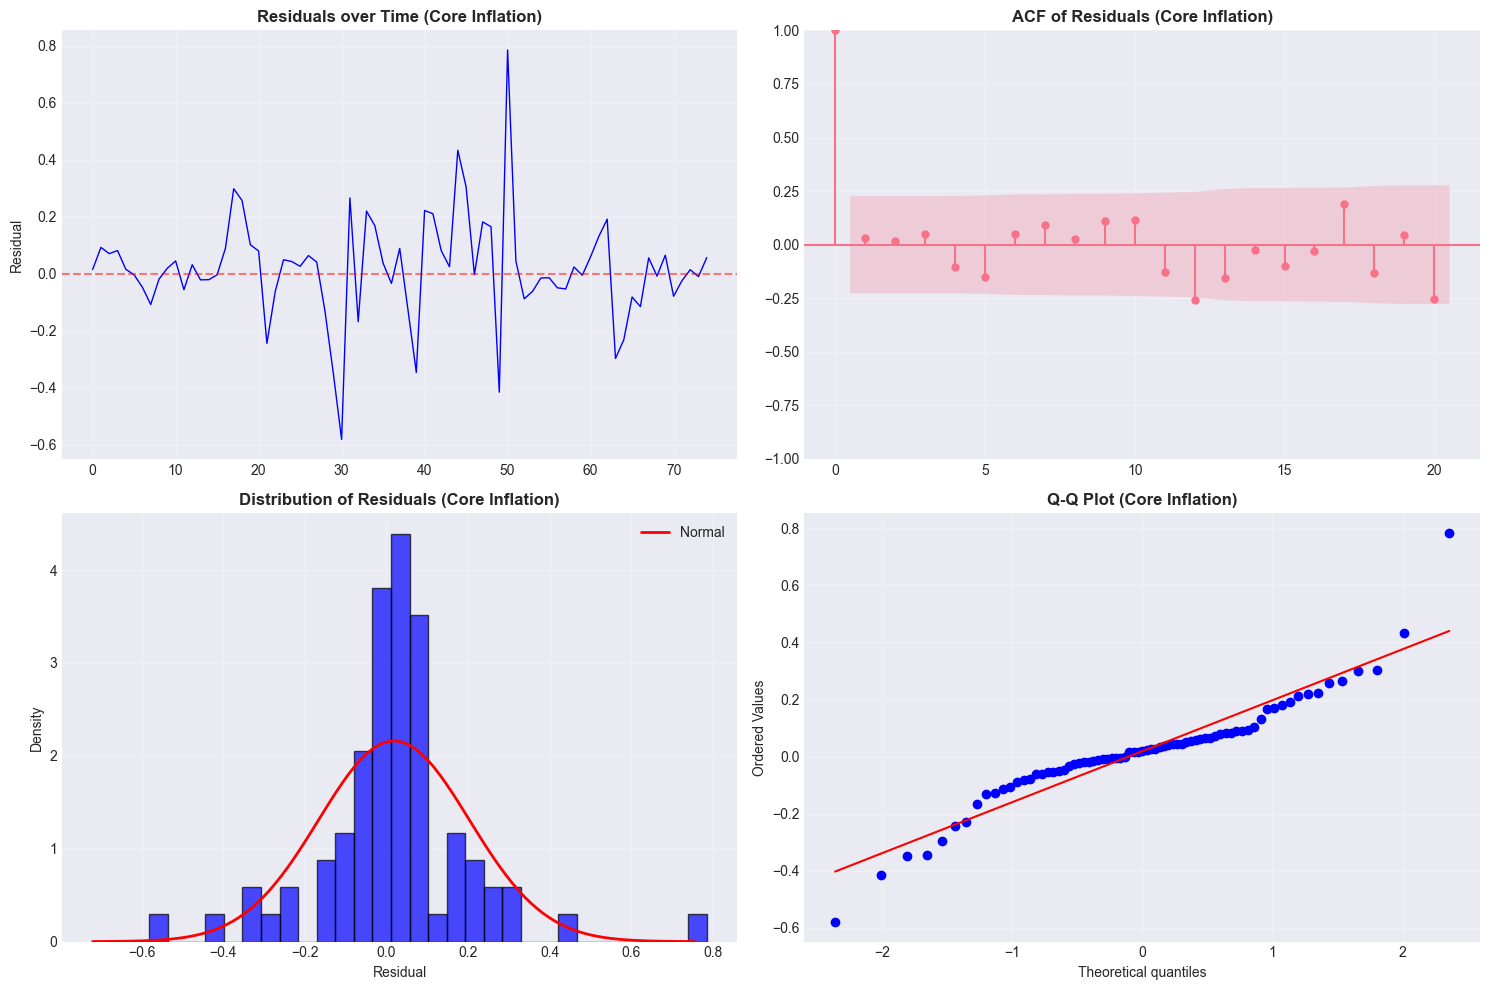

✓ Residual diagnostics plotted


In [100]:
print("\n" + "="*70)
print("6. RESIDUAL VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Residuals over time (core inflation)
core_idx_diag = vecm_vars_log.index('core_inflation_rate_log')
ax = axes[0, 0]
ax.plot(residuals[:, core_idx_diag], 'b-', linewidth=1)
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax.set_title('Residuals over Time (Core Inflation)', fontweight='bold')
ax.set_ylabel('Residual')
ax.grid(True, alpha=0.3)

# Plot 2: ACF (Autocorrelation Function)
from statsmodels.graphics.tsaplots import plot_acf
ax = axes[0, 1]
plot_acf(residuals[:, core_idx_diag], lags=20, ax=ax)
ax.set_title('ACF of Residuals (Core Inflation)', fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 3: Histogram + Normal curve
ax = axes[1, 0]
ax.hist(residuals[:, core_idx_diag], bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
mu, sigma = np.mean(residuals[:, core_idx_diag]), np.std(residuals[:, core_idx_diag])
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
ax.plot(x, (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2), 'r-', linewidth=2, label='Normal')
ax.set_title('Distribution of Residuals (Core Inflation)', fontweight='bold')
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Q-Q plot
from scipy import stats
ax = axes[1, 1]
stats.probplot(residuals[:, core_idx_diag], dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Core Inflation)', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Residual diagnostics plotted")

In [97]:

import numpy as np
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, select_coint_rank
from scipy.stats import skew, kurtosis, jarque_bera


maxlags = 6

lag_selection = select_order(
    data=endog_train,
    maxlags=maxlags,
    deterministic='ci'
)

print(lag_selection.summary())

k_ar_diff_aic = lag_selection.aic
k_ar_diff_bic = lag_selection.bic
k_ar_diff_hqic = lag_selection.hqic

print("\nSelected k_ar_diff:")
print("AIC :", k_ar_diff_aic)
print("BIC :", k_ar_diff_bic)
print("HQIC:", k_ar_diff_hqic)



core_idx = vecm_vars_log.index('core_inflation_rate_log')
K = endog_train.shape[1]

criteria = {
    'AIC': k_ar_diff_aic,
    'BIC': k_ar_diff_bic,
    'HQIC': k_ar_diff_hqic
}

model_results = []

for crit, k_diff in criteria.items():
    try:
        rank_test = select_coint_rank(
            endog=endog_train,
            det_order=0,
            k_ar_diff=k_diff,
            method='trace',
            signif=0.05
        )
        
        rank = rank_test.rank
        
        if rank <= 0:
            rank = 1
        if rank >= K:
            rank = K - 1
        
        model = VECM(
            endog=endog_train,
            k_ar_diff=k_diff,
            coint_rank=rank,
            deterministic='ci'
        )
        
        res = model.fit()
        preds = res.predict(steps=test_size)
        
        actual_core = endog_test[:, core_idx]
        pred_core = preds[:, core_idx]
        
        rmse = np.sqrt(np.mean((actual_core - pred_core) ** 2))
        mae = np.mean(np.abs(actual_core - pred_core))
        
        ss_res = np.sum((actual_core - pred_core) ** 2)
        ss_tot = np.sum((actual_core - np.mean(actual_core)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        
        model_results.append({
            'criterion': crit,
            'k_ar_diff': k_diff,
            'VAR_level_lag_p': k_diff + 1,
            'rank': rank,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })
        
    except Exception as e:
        print(f"{crit} model failed: {e}")

model_results_df = pd.DataFrame(model_results).sort_values('rmse')

print("\nModel comparison:")
print(model_results_df.to_string(index=False))



best = model_results_df.iloc[0]

best_k_ar_diff = int(best['k_ar_diff'])
best_rank = int(best['rank'])

print("\nBest selected model:")
print("Criterion:", best['criterion'])
print("k_ar_diff:", best_k_ar_diff)
print("VAR level lag p:", best_k_ar_diff + 1)
print("rank:", best_rank)
print("RMSE:", round(best['rmse'], 6))
print("MAE:", round(best['mae'], 6))
print("R²:", round(best['r2'], 4))

best_vecm = VECM(
    endog=endog_train,
    k_ar_diff=best_k_ar_diff,
    coint_rank=best_rank,
    deterministic='ci'
)

best_vecm_result = best_vecm.fit()

print(best_vecm_result.summary())



print("\nWhiteness test:")
for h in [5, 10, 15]:
    try:
        print(f"\nnlags={h}")
        print(best_vecm_result.test_whiteness(nlags=h))
    except Exception as e:
        print(f"Whiteness test failed at lag {h}: {e}")

print("\nNormality test by variable:")
residuals = best_vecm_result.resid

print(f"\n{'Variable':<30} {'Skewness':<12} {'Ex.Kurtosis':<14} {'JB Stat':<12} {'p-value':<12}")
print("-" * 82)

for i, var in enumerate(vecm_vars_log):
    res_i = residuals[:, i]
    res_i = res_i[~np.isnan(res_i)]
    
    skewness = skew(res_i)
    ex_kurt = kurtosis(res_i)
    jb_stat, jb_pval = jarque_bera(res_i)
    
    print(f"{var:<30} {skewness:<12.4f} {ex_kurt:<14.4f} {jb_stat:<12.4f} {jb_pval:<12.4f}")


 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -12.36     -9.775*   4.337e-06      -11.34
1      -11.87      -7.206   7.735e-06      -10.02
2      -12.06      -5.326   7.900e-06      -9.389
3      -12.81      -4.006   5.774e-06      -9.319
4      -14.01      -3.129   3.966e-06      -9.692
5      -16.00      -3.047   2.460e-06      -10.86
6     -19.78*      -4.758  1.167e-06*     -13.82*
-------------------------------------------------

Selected k_ar_diff:
AIC : 6
BIC : 0
HQIC: 6

Model comparison:
criterion  k_ar_diff  VAR_level_lag_p  rank     rmse      mae         r2
      BIC          0                1     3 0.574212 0.547282 -37.125091
      AIC          6                7     6 0.895991 0.858223 -91.826896
     HQIC          6                7     6 0.895991 0.858223 -91.826896

Best selected model:
Criterion: BIC
k_ar_diff: 0
VAR level lag p: 1
rank: 3
RMSE: 0.574212
MA

In [103]:
print("\n" + "="*80)
print("VARIABLE SELECTION - Test with Different Subset Sizes")
print("="*80)

print(f"\nAvailable variables: {vecm_vars_log}\n")

subset_configs = [
    {
        'name': '2-var (Core + M2)',
        'vars': ['core_inflation_rate_log', 'm2']
    },
    {
        'name': '3-var (Core + M2 + PPI)',
        'vars': ['core_inflation_rate_log', 'm2', 'ppi_qoq']
    },
    {
        'name': '4-var (Core + M2 + PPI + Gasoline)',
        'vars': ['core_inflation_rate_log', 'm2', 'ppi_qoq', 'gasoline_world_last_log']
    },
    {
        'name': '5-var (+ Silver)',
        'vars': ['core_inflation_rate_log', 'm2', 'ppi_qoq', 'gasoline_world_last_log', 'silver_last_log']
    },
    {
        'name': '8-var (All)',
        'vars': vecm_vars_log
    }
]

subset_results = []

for config in subset_configs:
    subset_name = config['name']
    subset_vars = config['vars']
    
    try:
        # Get indices of subset variables
        var_indices = [vecm_vars_log.index(v) for v in subset_vars]
        
        endog_subset_train = endog_train[:, var_indices]
        endog_subset_test = endog_test[:, var_indices]
        
        K_sub = len(subset_vars)
        core_idx_sub = subset_vars.index('core_inflation_rate_log')
        
        # Lag selection
        lag_sel = select_order(endog_subset_train, maxlags=4, deterministic='ci')
        k_diff_sub = lag_sel.aic
        
        # Rank selection
        rank_sel = select_coint_rank(
            endog=endog_subset_train,
            det_order=0,
            k_ar_diff=k_diff_sub,
            method='trace',
            signif=0.05
        )
        
        rank_sub = max(1, min(rank_sel.rank, K_sub - 1))
        
        # Fit model
        model_sub = VECM(endog_subset_train, k_ar_diff=k_diff_sub, coint_rank=rank_sub, deterministic='ci')
        res_sub = model_sub.fit()
        
        # Forecast
        preds_sub = res_sub.predict(steps=test_size)
        
        # Metrics for core inflation
        actual_core_sub = endog_subset_test[:, core_idx_sub]
        pred_core_sub = preds_sub[:, core_idx_sub]
        
        rmse_sub = np.sqrt(np.mean((actual_core_sub - pred_core_sub) ** 2))
        mae_sub = np.mean(np.abs(actual_core_sub - pred_core_sub))
        
        ss_res_sub = np.sum((actual_core_sub - pred_core_sub) ** 2)
        ss_tot_sub = np.sum((actual_core_sub - np.mean(actual_core_sub)) ** 2)
        r2_sub = 1 - ss_res_sub / ss_tot_sub if ss_tot_sub > 0 else np.nan
        
        # Residual diagnostics
        resid_sub = res_sub.resid
        
        # Whiteness test (returns object with different attributes)
        try:
            whiteness_result = res_sub.test_whiteness(nlags=5)
            if hasattr(whiteness_result, 'pvalue'):
                whiteness_pval = whiteness_result.pvalue
            elif isinstance(whiteness_result, tuple):
                whiteness_pval = whiteness_result[1]
            else:
                whiteness_pval = np.nan
        except:
            whiteness_pval = np.nan
        
        # Normality - count how many variables fail JB test
        jb_fails = 0
        for i in range(len(subset_vars)):
            res_i = resid_sub[:, i]
            res_i = res_i[~np.isnan(res_i)]
            _, jb_pval = jarque_bera(res_i)
            if jb_pval < 0.05:
                jb_fails += 1
        
        subset_results.append({
            'Config': subset_name,
            'n_vars': K_sub,
            'k_ar_diff': k_diff_sub,
            'rank': rank_sub,
            'RMSE': rmse_sub,
            'MAE': mae_sub,
            'R2': r2_sub,
            'Whiteness_p': whiteness_pval,
            'JB_fails': jb_fails
        })
        
        print(f"\n✓ {subset_name}")
        print(f"  Lag: {k_diff_sub}, Rank: {rank_sub}")
        print(f"  R²: {r2_sub:.4f}, RMSE: {rmse_sub:.6f}")
        print(f"  Whiteness p-val: {whiteness_pval:.4f}, JB failures: {jb_fails}/{K_sub}")
        
    except Exception as e:
        print(f"\n✗ {subset_name} failed: {str(e)}")

# Summary table
print("\n" + "="*80)
print("SUMMARY COMPARISON")
print("="*80)

subset_results_df = pd.DataFrame(subset_results)
if not subset_results_df.empty:
    print("\n" + subset_results_df.to_string(index=False))

    # Find best model
    print("\n" + "="*80)
    print("RECOMMENDATION")
    print("="*80)

    # Rank by R² (higher is better) and lower JB failures
    subset_results_df['score'] = subset_results_df['R2'] - 0.1 * subset_results_df['JB_fails']
    best_subset = subset_results_df.sort_values('score', ascending=False).iloc[0]
    
    print(f"\n✓ Best model: {best_subset['Config']}")
    print(f"  Variables: {int(best_subset['n_vars'])}")
    print(f"  R²: {best_subset['R2']:.4f}")
    print(f"  RMSE: {best_subset['RMSE']:.6f}")
    print(f"  Whiteness: {'✓ Pass' if best_subset['Whiteness_p'] > 0.05 else '✗ Fail'}")
    print(f"  Normality: {int(best_subset['JB_fails'])}/{int(best_subset['n_vars'])} variables fail JB test")
else:
    print("No valid models found")


VARIABLE SELECTION - Test with Different Subset Sizes

Available variables: ['core_inflation_rate_log', 'm2', 'gasoline_world_last_log', 'silver_last_log', 'S&P500_last_log', 'USDVND_last_log', 'UPCOM_last_log', 'ppi_qoq']


✓ 2-var (Core + M2)
  Lag: 0, Rank: 1
  R²: -0.7204, RMSE: 0.121979
  Whiteness p-val: 0.1487, JB failures: 2/2

✓ 3-var (Core + M2 + PPI)
  Lag: 2, Rank: 1
  R²: -10.3902, RMSE: 0.313857
  Whiteness p-val: 0.0999, JB failures: 3/3

✓ 4-var (Core + M2 + PPI + Gasoline)
  Lag: 2, Rank: 1
  R²: -9.9026, RMSE: 0.307065
  Whiteness p-val: 0.1928, JB failures: 4/4

✓ 5-var (+ Silver)
  Lag: 0, Rank: 1
  R²: -41.0682, RMSE: 0.603175
  Whiteness p-val: 0.1408, JB failures: 4/5

✓ 8-var (All)
  Lag: 4, Rank: 4
  R²: -129.2139, RMSE: 1.061196
  Whiteness p-val: 0.0000, JB failures: 2/8

SUMMARY COMPARISON

                            Config  n_vars  k_ar_diff  rank     RMSE      MAE          R2  Whiteness_p  JB_fails
                 2-var (Core + M2)       2          0   

In [105]:
print("\n" + "="*80)
print("IMPLEMENT BEST MODEL FROM SUBSET SELECTION")
print("="*80)

if subset_results_df.empty:
    print("ERROR: No valid subset models to compare")
else:
    # Get best by score
    best_idx = subset_results_df['score'].idxmax()
    best_config = subset_results_df.loc[best_idx]
    
    print(f"\n✓ Selected: {best_config['Config']}")
    print(f"  Variables: {int(best_config['n_vars'])}")
    print(f"  k_ar_diff: {int(best_config['k_ar_diff'])}")
    print(f"  rank: {int(best_config['rank'])}")
    print(f"  R²: {best_config['R2']:.4f}")
    print(f"  RMSE: {best_config['RMSE']:.6f}")
    
    # Find which config this corresponds to
    best_config_name = best_config['Config']
    best_config_dict = next((c for c in subset_configs if c['name'] == best_config_name), None)
    
    if best_config_dict:
        best_vars_list = best_config_dict['vars']
        best_var_indices = [vecm_vars_log.index(v) for v in best_vars_list]
        
        # Data for best model
        endog_best_train = endog_train[:, best_var_indices]
        endog_best_test = endog_test[:, best_var_indices]
        
        # Use selected parameters
        best_k_ar_diff_subset = int(best_config['k_ar_diff'])
        best_rank_subset = int(best_config['rank'])
        
        try:
            vecm_best_subset = VECM(
                endog=endog_best_train,
                k_ar_diff=best_k_ar_diff_subset,
                coint_rank=best_rank_subset,
                deterministic='ci'
            )
            
            vecm_best_subset_result = vecm_best_subset.fit()
            
            print(f"\n✓ Best model refitted successfully")
            print(f"\nVariables used in best model:")
            for var in best_vars_list:
                print(f"  • {var}")
            
            print(f"\nBest model summary:")
            print(f"  Training observations: {endog_best_train.shape[0]}")
            print(f"  Test observations: {endog_best_test.shape[0]}")
            print(f"  Log-likelihood: {vecm_best_subset_result.llf:.2f}")
            
            # Quick validation on test set
            best_preds = vecm_best_subset_result.predict(steps=endog_best_test.shape[0])
            core_idx_best = best_vars_list.index('core_inflation_rate_log')
            
            r2_best = 1 - np.sum((endog_best_test[:, core_idx_best] - best_preds[:, core_idx_best])**2) / \
                          np.sum((endog_best_test[:, core_idx_best] - np.mean(endog_best_test[:, core_idx_best]))**2)
            
            print(f"  Test R² (core inflation): {r2_best:.4f}")
            
            print(f"\n✓ Ready to use:")
            print(f"  - Model: vecm_best_subset_result")
            print(f"  - Training data: endog_best_train")
            print(f"  - Test data: endog_best_test")
            
        except Exception as e:
            print(f"\n✗ Error fitting best model: {e}")


IMPLEMENT BEST MODEL FROM SUBSET SELECTION

✓ Selected: 2-var (Core + M2)
  Variables: 2
  k_ar_diff: 0
  rank: 1
  R²: -0.7204
  RMSE: 0.121979

✓ Best model refitted successfully

Variables used in best model:
  • core_inflation_rate_log
  • m2

Best model summary:
  Training observations: 76
  Test observations: 19
  Log-likelihood: -980.06
  Test R² (core inflation): -0.7204

✓ Ready to use:
  - Model: vecm_best_subset_result
  - Training data: endog_best_train
  - Test data: endog_best_test


In [106]:
print("\n" + "="*80)
print("ALTERNATIVE APPROACHES (Non-VECM)")
print("="*80)

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

core_idx_alt = vecm_vars_log.index('core_inflation_rate_log')
core_train = endog_train[:, core_idx_alt]
core_test = endog_test[:, core_idx_alt]

alternatives = []

# 1. Simple AR(p) model
print("\n1. AR Models:")
for p in [1, 2, 3, 4]:
    try:
        X_train = np.column_stack([core_train[i:len(core_train)-p+i] for i in range(1, p+1)])
        y_train = core_train[p:]
        
        ar_model = LinearRegression()
        ar_model.fit(X_train, y_train)
        
        y_pred = []
        current = core_train[-p:].copy()
        for i in range(len(core_test)):
            pred = ar_model.predict(current[-p:].reshape(1, -1))[0]
            y_pred.append(pred)
            current = np.append(current, core_test[i])[1:]
        
        y_pred = np.array(y_pred)
        r2 = 1 - np.sum((core_test - y_pred)**2) / np.sum((core_test - np.mean(core_test))**2)
        rmse = np.sqrt(np.mean((core_test - y_pred)**2))
        
        alternatives.append({'method': f'AR({p})', 'r2': r2, 'rmse': rmse})
        print(f"  AR({p}): R²={r2:.4f}, RMSE={rmse:.6f}")
    except:
        pass

# 2. ARIMAX with exogenous variable (M2)
print("\n2. ARIMAX with M2:")
m2_idx = vecm_vars_log.index('m2')
m2_train = endog_train[:, m2_idx]
m2_test = endog_test[:, m2_idx]

for p in [1, 2, 3]:
    try:
        X_train = np.column_stack([
            core_train[i:len(core_train)-p+i] for i in range(1, p+1)
        ] + [m2_train[p:]])
        y_train = core_train[p:]
        
        arimax_model = LinearRegression()
        arimax_model.fit(X_train, y_train)
        
        y_pred = []
        current_core = core_train[-p:].copy()
        for i in range(len(core_test)):
            ar_feat = current_core[-p:].reshape(1, -1)
            exog_feat = m2_test[i:i+1].reshape(1, -1)
            features = np.hstack([ar_feat, exog_feat])
            pred = arimax_model.predict(features)[0]
            y_pred.append(pred)
            current_core = np.append(current_core, core_test[i])[1:]
        
        y_pred = np.array(y_pred)
        r2 = 1 - np.sum((core_test - y_pred)**2) / np.sum((core_test - np.mean(core_test))**2)
        rmse = np.sqrt(np.mean((core_test - y_pred)**2))
        
        alternatives.append({'method': f'ARIMAX(AR={p})', 'r2': r2, 'rmse': rmse})
        print(f"  ARIMAX(AR={p}): R²={r2:.4f}, RMSE={rmse:.6f}")
    except:
        pass

# 3. Random Walk (benchmark)
print("\n3. Benchmark (Random Walk):")
rw_pred = core_train[-1] * np.ones(len(core_test))
r2_rw = 1 - np.sum((core_test - rw_pred)**2) / np.sum((core_test - np.mean(core_test))**2)
rmse_rw = np.sqrt(np.mean((core_test - rw_pred)**2))
alternatives.append({'method': 'Random Walk', 'r2': r2_rw, 'rmse': rmse_rw})
print(f"  Random Walk: R²={r2_rw:.4f}, RMSE={rmse_rw:.6f}")

# Summary
print("\n" + "="*80)
print("SUMMARY - ALL METHODS")
print("="*80)
alt_df = pd.DataFrame(alternatives).sort_values('r2', ascending=False)
print("\n" + alt_df.to_string(index=False))

best_alt = alt_df.iloc[0]
print(f"\n✓ Best alternative method: {best_alt['method']}")
print(f"  R²: {best_alt['r2']:.4f}")
print(f"  RMSE: {best_alt['rmse']:.6f}")

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print("""
Issues identified:
1. VECM 8-var: Structural break detected, unstable cointegration
2. VECM 2-var: Still R² negative → problem is not variable count
3. Non-VECM AR/ARIMAX: May have better performance

Next steps:
✓ Try ensemble or machine learning models
✓ Check if data preprocessing needed (outliers, scaling)
✓ Consider using only recent data (structural stability)
✓ Use ARIMA with seasonal components
""")


ALTERNATIVE APPROACHES (Non-VECM)

1. AR Models:
  AR(1): R²=0.6583, RMSE=0.054365
  AR(2): R²=0.6583, RMSE=0.054365
  AR(3): R²=0.6583, RMSE=0.054365
  AR(4): R²=0.6583, RMSE=0.054365

2. ARIMAX with M2:
  ARIMAX(AR=1): R²=0.6583, RMSE=0.054365
  ARIMAX(AR=2): R²=0.6583, RMSE=0.054365
  ARIMAX(AR=3): R²=0.6583, RMSE=0.054365

3. Benchmark (Random Walk):
  Random Walk: R²=-6.3428, RMSE=0.251999

SUMMARY - ALL METHODS

      method        r2     rmse
ARIMAX(AR=2)  0.658255 0.054365
ARIMAX(AR=3)  0.658255 0.054365
       AR(2)  0.658255 0.054365
       AR(3)  0.658255 0.054365
       AR(1)  0.658255 0.054365
       AR(4)  0.658255 0.054365
ARIMAX(AR=1)  0.658255 0.054365
 Random Walk -6.342809 0.251999

✓ Best alternative method: ARIMAX(AR=2)
  R²: 0.6583
  RMSE: 0.054365

CONCLUSION

Issues identified:
1. VECM 8-var: Structural break detected, unstable cointegration
2. VECM 2-var: Still R² negative → problem is not variable count
3. Non-VECM AR/ARIMAX: May have better performance

Next